In [1]:
%pip install d2l --no-deps --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.7 MB/s eta 0:00:00


In [2]:
# ===== 导入依赖 =====
import torch  # 张量运算与随机数生成
from torch import nn  # 神经网络模块，后续定义可学习参数与损失函数
from d2l import torch as d2l  # d2l 的 PyTorch 工具（绘图/动画等）

In [3]:
# ===== 1) 生成训练数据与测试数据 =====

# 训练样本数量
n_train = 50

# 在 [0, 5) 区间随机采样 n_train 个 x，并排序（便于后续可视化）
# torch.rand(n_train) 先在 [0,1) 采样，再乘 5 映射到 [0,5)
x_train, _ = torch.sort(torch.rand(n_train) * 5)

def f(x):
    """真实函数（目标函数）。"""
    return 2 * torch.sin(x) + x ** 0.8

# 训练标签：真实函数值 + 高斯噪声
# torch.normal(mean, std, shape) 这里表示均值 0、标准差 0.5 的噪声
y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))

# 构造测试输入：0 到 5，步长 0.1，共 50 个点
x_test = torch.arange(0, 5, 0.1)

# 测试集“真值”（无噪声），用于评估预测曲线是否贴近真实函数
y_truth = f(x_test)

# 测试样本数量
n_test = len(x_test)
print(n_test)

50


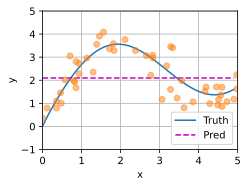

In [4]:
def plot_kernel_reg(y_hat):
    """
    绘制核回归预测结果。

    参数
    ----
    y_hat : torch.Tensor
        模型预测值，长度应与 x_test 一致。
    """
    # d2l.plot 同时绘制真值曲线与预测曲线
    # x 轴: 输入 x；y 轴: 输出 y
    d2l.plot(
        x_test, [y_truth, y_hat], 'x', 'y',
        legend=['Truth', 'Pred'], xlim=[0, 5], ylim=[-1, 5]
    )

    # 叠加训练散点，观察模型是否能贴合训练分布
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

# ===== 2) 基线模型：所有测试点都预测为训练标签均值 =====
# torch.repeat_interleave(value, n_test): 复制均值 n_test 次形成向量
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

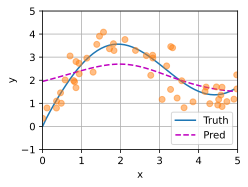

In [5]:
# ===== 3) 非参数注意力池化（Nadaraya-Watson 核回归） =====

# X_repeat 形状: (n_test, n_train)
# 含义：每一行都是“同一个测试输入 x_test[i]”复制 n_train 次
# 目的：与所有训练输入 x_train 做逐元素距离计算
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))

# 计算高斯核注意力权重：softmax(- (q-k)^2 / 2)
# - q 是 query（测试输入）
# - k 是 key（训练输入）
# dim=1 表示在每个 query 对应的所有 key 上归一化，使权重和为 1
attention_weights = nn.functional.softmax(-(X_repeat - x_train) ** 2 / 2, dim=1)

# 预测值 = 注意力权重对训练标签 y_train 的加权平均
# matmul 形状: (n_test, n_train) @ (n_train,) -> (n_test,)
y_hat = torch.matmul(attention_weights, y_train)

# 可视化预测曲线
plot_kernel_reg(y_hat)

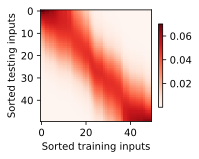

In [6]:
# 将 attention_weights 扩展为 4 维，满足 d2l.show_heatmaps 输入格式：
# (num_rows, num_cols, num_queries, num_keys) = (1, 1, n_test, n_train)
d2l.show_heatmaps(
    attention_weights.unsqueeze(0).unsqueeze(0),
    xlabel='Sorted training inputs',
    ylabel='Sorted testing inputs'
 )

In [7]:
# ===== 4) 理解批量矩阵乘法 torch.bmm =====
# bmm 要求输入都是 3 维张量： (batch, m, n) @ (batch, n, p) -> (batch, m, p)

# 构造两个批量张量
X = torch.ones((2, 1, 4))  # batch=2, m=1, n=4
Y = torch.ones((2, 4, 6))  # batch=2, n=4, p=6

# 结果形状应为 (2, 1, 6)
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [8]:
# 再举一个更贴近注意力的 bmm 示例：

# weights: 每个 batch 的注意力权重（10 个权重，总和约为 1）
weights = torch.ones((2, 10)) * 0.1

# values: 每个 batch 的 10 个 value
values = torch.arange(20.0).reshape((2, 10))

# 通过 unsqueeze 调整形状后进行 bmm：
# weights.unsqueeze(1): (2, 1, 10)
# values.unsqueeze(-1): (2, 10, 1)
# 输出: (2, 1, 1)，本质是每个 batch 的“加权和”
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

In [9]:
class NWKernelRegression(nn.Module):
    """
    带可学习带宽参数的 Nadaraya-Watson 核回归。

    与前面的“非参数版本”相比：
    - 非参数版本固定使用 exp(- (q-k)^2 / 2)；
    - 这里引入可学习参数 w，核函数变为 exp(- ((q-k)*w)^2 / 2)。
    - 训练后可自适应“注意力分布”的尖锐程度。
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        # 可学习标量参数 w（初始随机）
        # nn.Parameter 会被自动加入模型参数，参与梯度更新
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        """
        前向计算。

        参数
        ----
        queries : torch.Tensor
            形状 (n_query,) 或可等价展平为 n_query。
        keys : torch.Tensor
            形状 (n_query, n_kv)。每个 query 对应一组 key。
        values : torch.Tensor
            形状 (n_query, n_kv)。与 keys 一一对应的 value。

        返回
        ----
        output : torch.Tensor
            形状 (n_query,)。每个查询对应一个预测值。
        """
        # 将 queries 扩展到与 keys 对齐：
        # repeat_interleave 后 reshape -> (n_query, n_kv)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))

        # 计算注意力权重（沿 key 维度归一化）
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w) ** 2 / 2, dim=1
        )

        # 对 values 做加权求和：
# attention_weights.unsqueeze(1): (n_query, 1, n_kv)
# values.unsqueeze(-1):          (n_query, n_kv, 1)
# bmm 输出:                      (n_query, 1, 1)
        return torch.bmm(
            self.attention_weights.unsqueeze(1), values.unsqueeze(-1)
        ).reshape(-1)

In [10]:
# ===== 5) 为训练阶段构造 keys / values（留一法） =====
# 目标：训练时每个样本都作为 query，但不能把自己当作 key/value（避免“偷看答案”）。

# X_tile 形状: (n_train, n_train)
# 每一行都是完整的 x_train
X_tile = x_train.repeat((n_train, 1))

# Y_tile 形状: (n_train, n_train)
# 每一行都是完整的 y_train
Y_tile = y_train.repeat((n_train, 1))

# 构造布尔掩码：单位矩阵对角线为 True，1-eye 后对角线为 0，非对角线为 1
# 转 bool 后，True 表示保留非对角元素（即“除自己之外的其他样本”）
mask = (1 - torch.eye(n_train)).type(torch.bool)

# keys 形状: (n_train, n_train - 1)
# 第 i 行表示第 i 个 query 可见的所有 key（不含自身）
keys = X_tile[mask].reshape((n_train, -1))

# values 形状: (n_train, n_train - 1)
# 与 keys 一一对应的标签值
values = Y_tile[mask].reshape((n_train, -1))

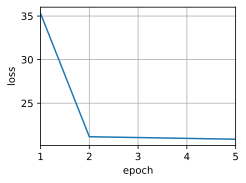

In [11]:
# ===== 6) 训练带可学习参数的 NW 核回归模型 =====
net = NWKernelRegression()

# MSELoss(reduction='none')：先保留逐样本损失，后面手动 sum
loss = nn.MSELoss(reduction='none')

# 使用 SGD 优化器更新参数 w
trainer = torch.optim.SGD(net.parameters(), lr=0.5)

# 可视化训练损失曲线
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

# 训练 5 个 epoch
for epoch in range(5):
    # 清空上一步梯度，避免梯度累计
    trainer.zero_grad()

    # 前向计算 + 损失（query 使用训练输入 x_train）
    l = loss(net(x_train, keys, values), y_train)

    # 反向传播：这里把逐样本损失求和后反向传播
    l.sum().backward()

    # 参数更新
    trainer.step()

    # 打印与记录当前 epoch 的总损失
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

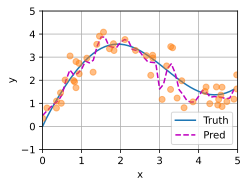

In [12]:
# ===== 7) 在测试集上做预测 =====

# 对每个测试 query，都使用完整训练集作为 key/value
# keys 形状: (n_test, n_train)
keys = x_train.repeat((n_test, 1))

# values 形状: (n_test, n_train)
values = y_train.repeat((n_test, 1))

# 模型输出形状 (n_test,)，unsqueeze(1) 变成列向量，便于与绘图函数兼容
# detach() 将结果从计算图中分离，表示后续仅用于可视化
y_hat = net(x_test, keys, values).unsqueeze(1).detach()

# 绘制预测结果
plot_kernel_reg(y_hat)

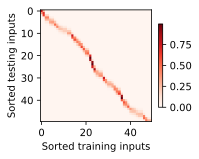

In [13]:
# ===== 8) 可视化“可学习模型”得到的注意力权重 =====
# net.attention_weights 形状通常为 (n_test, n_train)
# 扩展成 4 维以适配 show_heatmaps: (1, 1, n_test, n_train)
d2l.show_heatmaps(
    net.attention_weights.unsqueeze(0).unsqueeze(0),
    xlabel='Sorted training inputs',
    ylabel='Sorted testing inputs'
 )